In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
import sys
import os
sys.path.append('../utils')
import database as db

# Create output directory if it doesn't exist
if not os.path.exists("fig/rq7"):
    os.makedirs("fig/rq7")

connect to CVEFIXes


# Experiment 7: Severity × Vulnerability Type Cross-Tabulation

## Research Question
For each severity level, what percentage are memory vs. resource management vs. other vulnerability types?
Are memory vulnerabilities more/less severe than resource management vulnerabilities?

## Methodology
This analysis cross-tabulates vulnerability severity (Critical, High, Medium, Low, None) with SFP categories, focusing on:
- **Memory vulnerabilities**: Memory Access, Memory Management
- **Resource Management (RM)**: Resource Management
- **Other**: All other categories

## Hypothesis
If memory bugs are more severe, their decline is even more important for ecosystem security.

In [2]:
# Load vulnerability data with severity and SFP categories.
# NOTE: one CVE can carry several SFP categories (1,790 CVE-SFP pairs for 1,245
# unique CVEs), so df has one row per (CVE, category). Deduplication by CVE
# happens after type classification in the next cell.
df = pd.read_sql("""
    SELECT 
        c.id,
        c.package,
        c.severity,
        s.sfp_category
    FROM cve c
    JOIN cve_sfp s ON c.id = s.cve_id
""", con=db.conn)

# Normalize severity: treat empty/whitespace as missing (no severity score).
# These CVEs are excluded from all severity-based analyses below (documented).
df['severity'] = df['severity'].replace(r'^\s*$', np.nan, regex=True)

n_blank = df.loc[df['severity'].isna(), 'id'].nunique()
n_none = df.loc[df['severity'] == 'None', 'id'].nunique()

print(f"Total vulnerability-SFP pairs: {len(df)}")
print(f"Unique vulnerabilities: {df['id'].nunique()}")
print(f"\nSeverity data quality (unique CVEs):")
print(f"  {n_blank} CVEs with blank/empty severity -> no score, excluded from severity analyses")
print(f"  {n_none} CVEs with severity 'None' -> scored as 0 in comparisons")
print(f"\nSeverity distribution (unique CVEs):")
print(df.drop_duplicates('id').groupby('severity')['id'].nunique().sort_values(ascending=False))
print(f"\nSFP category distribution (CVE-SFP pairs):")
print(df['sfp_category'].value_counts())


Total vulnerability-SFP pairs: 1790
Unique vulnerabilities: 1245

Severity data quality (unique CVEs):
  42 CVEs with blank/empty severity -> no score, excluded from severity analyses
  2 CVEs with severity 'None' -> scored as 0 in comparisons

Severity distribution (unique CVEs):
severity
Medium      458
High        445
Critical    151
Low         147
None          2
Name: id, dtype: int64

SFP category distribution (CVE-SFP pairs):
sfp_category
Resource Management     267
Memory Management       256
Memory Access           249
Tainted Input           187
Exception Management    122
Synchronization         107
Cryptography            107
Other                    99
Path Resolution          81
Risky Values             75
Information Leak         70
Authentication           57
Access Control           42
API                      34
Privilege                27
Predictability            9
Entry Points              1
Name: count, dtype: int64


## Define Vulnerability Type Groups

In [3]:
# Define vulnerability type groups
def classify_vul_type(sfp_category):
    """Classify SFP category into Memory, Resource Management, or Other."""
    memory_categories = ['Memory Access', 'Memory Management']
    rm_categories = ['Resource Management']
    
    if sfp_category in memory_categories:
        return 'Memory'
    elif sfp_category in rm_categories:
        return 'Resource Management'
    else:
        return 'Other'

# Apply classification
df['vul_type'] = df['sfp_category'].apply(classify_vul_type)

# Deduplicate by CVE: assign each CVE a single primary vul_type so it is never
# double-counted in the severity cross-tab or in the group comparisons.
# Priority: Memory > Resource Management > Other. This notebook's research focus
# is the Memory vs Resource Management contrast, so a CVE spanning several groups
# is counted in the most specific/analyzed group. 432 CVEs have >1 category.
priority = {'Memory': 3, 'Resource Management': 2, 'Other': 1}
df_cve = (df.assign(_p=df['vul_type'].map(priority))
            .sort_values('_p', ascending=False, kind='stable')
            .drop_duplicates('id')
            .drop(columns='_p'))

print("Vulnerability type distribution (CVE-SFP pairs, before dedup):")
print(df['vul_type'].value_counts())
print(f"\nVulnerability type distribution (unique CVEs, primary type):")
print(df_cve['vul_type'].value_counts())
print(f"\nPercentages (unique CVEs):")
print(df_cve['vul_type'].value_counts(normalize=True) * 100)
print(f"\nDeduplicated by CVE: {len(df)} pair rows -> {len(df_cve)} unique CVEs "
      f"({len(df) - len(df_cve)} multi-category rows collapsed)")


Vulnerability type distribution (CVE-SFP pairs, before dedup):
vul_type
Other                  1018
Memory                  505
Resource Management     267
Name: count, dtype: int64

Vulnerability type distribution (unique CVEs, primary type):
vul_type
Other                  643
Memory                 409
Resource Management    193
Name: count, dtype: int64

Percentages (unique CVEs):
vul_type
Other                  51.646586
Memory                 32.851406
Resource Management    15.502008
Name: proportion, dtype: float64

Deduplicated by CVE: 1790 pair rows -> 1245 unique CVEs (545 multi-category rows collapsed)


## Cross-Tabulation: Severity × Vulnerability Type

In [4]:
# Create cross-tabulation: count of each (severity, vul_type) combination.
# Built from df_cve (one row per CVE, primary vul_type), so every vulnerability
# is counted exactly once per cell. CVEs with blank severity (NaN) are excluded
# by pd.crosstab; they have no severity level (count documented in cell 2).
cross_tab = pd.crosstab(df_cve['severity'], df_cve['vul_type'])
print("Cross-tabulation (raw counts, one CVE per cell):")
print(cross_tab)
print()

# Method 2: Row percentages (within each severity level)
cross_tab_pct = pd.crosstab(df_cve['severity'], df_cve['vul_type'], normalize='index') * 100
print("Cross-tabulation (row percentages):")
print(cross_tab_pct.round(2))

n_no_score = df_cve['severity'].isna().sum()
print(f"\nNote: {n_no_score} CVEs have no severity score (blank severity) and are "
      f"excluded from the cross-tabulation above.")


Cross-tabulation (raw counts, one CVE per cell):
vul_type  Memory  Other  Resource Management
severity                                    
Critical      79     64                    8
High         146    200                   99
Low           31    102                   14
Medium       123    266                   69
None           1      1                    0

Cross-tabulation (row percentages):
vul_type  Memory  Other  Resource Management
severity                                    
Critical   52.32  42.38                 5.30
High       32.81  44.94                22.25
Low        21.09  69.39                 9.52
Medium     26.86  58.08                15.07
None       50.00  50.00                 0.00

Note: 42 CVEs have no severity score (blank severity) and are excluded from the cross-tabulation above.


## Detailed Analysis by Severity Level

In [5]:
# Analyze each severity level
severity_order = ['Critical', 'High', 'Medium', 'Low', 'None']
vul_types = ['Memory', 'Resource Management', 'Other']

print("=" * 70)
print("SEVERITY × VULNERABILITY TYPE ANALYSIS")
print("=" * 70)

for severity in severity_order:
    if severity not in cross_tab.index:
        continue
    
    print(f"\n{severity}:")
    total = cross_tab.loc[severity].sum()
    
    for vul_type in vul_types:
        if vul_type in cross_tab.columns:
            count = cross_tab.loc[severity, vul_type]
            pct = cross_tab_pct.loc[severity, vul_type]
            print(f"  {vul_type:20s}: {count:3d} ({pct:5.2f}%)")
    print(f"  {'Total':20s}: {total:3d}")

SEVERITY × VULNERABILITY TYPE ANALYSIS

Critical:
  Memory              :  79 (52.32%)
  Resource Management :   8 ( 5.30%)
  Other               :  64 (42.38%)
  Total               : 151

High:
  Memory              : 146 (32.81%)
  Resource Management :  99 (22.25%)
  Other               : 200 (44.94%)
  Total               : 445

Medium:
  Memory              : 123 (26.86%)
  Resource Management :  69 (15.07%)
  Other               : 266 (58.08%)
  Total               : 458

Low:
  Memory              :  31 (21.09%)
  Resource Management :  14 ( 9.52%)
  Other               : 102 (69.39%)
  Total               : 147

None:
  Memory              :   1 (50.00%)
  Resource Management :   0 ( 0.00%)
  Other               :   1 (50.00%)
  Total               :   2


## Statistical Test: Are Memory Vulns More Severe than Resource Management?

In [6]:
# Assign numeric severity scores for statistical testing.
# Ordinal mapping (arbitrary but common): Critical=4, High=3, Medium=2, Low=1,
# None=0. CVEs with blank severity (NaN) get no score and are dropped via
# .dropna() below (42 CVEs, documented in cell 2); 'None' is scored 0 (2 CVEs).
severity_map = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1, 'None': 0}
df_cve['severity_score'] = df_cve['severity'].map(severity_map)

# Groups are disjoint: df_cve assigns each CVE a single primary vul_type, so the
# Mann-Whitney / Kruskal-Wallis comparisons below do not double-count
# multi-category CVEs.
memory_scores = df_cve[df_cve['vul_type'] == 'Memory']['severity_score'].dropna()
rm_scores = df_cve[df_cve['vul_type'] == 'Resource Management']['severity_score'].dropna()
other_scores = df_cve[df_cve['vul_type'] == 'Other']['severity_score'].dropna()

print(f"Note: {int(df_cve['severity_score'].isna().sum())} CVEs with blank severity "
      f"excluded from the comparisons below (no severity score).")

print("=" * 70)
print("STATISTICAL COMPARISON: MEMORY vs RESOURCE MANAGEMENT")
print("=" * 70)
print(f"\nMemory vulnerabilities:")
print(f"  Count: {len(memory_scores)}")
print(f"  Mean severity: {memory_scores.mean():.2f}")
print(f"  Median severity: {memory_scores.median():.2f}")
print(f"  Std dev: {memory_scores.std():.2f}")
print(f"  Severity distribution:")
print(memory_scores.value_counts().sort_index())

print(f"\nResource Management vulnerabilities:")
print(f"  Count: {len(rm_scores)}")
print(f"  Mean severity: {rm_scores.mean():.2f}")
print(f"  Median severity: {rm_scores.median():.2f}")
print(f"  Std dev: {rm_scores.std():.2f}")
print(f"  Severity distribution:")
print(rm_scores.value_counts().sort_index())

print(f"\nOther vulnerabilities:")
print(f"  Count: {len(other_scores)}")
print(f"  Mean severity: {other_scores.mean():.2f}")
print(f"  Median severity: {other_scores.median():.2f}")
print(f"  Std dev: {other_scores.std():.2f}")


Note: 42 CVEs with blank severity excluded from the comparisons below (no severity score).
STATISTICAL COMPARISON: MEMORY vs RESOURCE MANAGEMENT

Memory vulnerabilities:
  Count: 380
  Mean severity: 2.71
  Median severity: 3.00
  Std dev: 0.90
  Severity distribution:
severity_score
0.0      1
1.0     31
2.0    123
3.0    146
4.0     79
Name: count, dtype: int64

Resource Management vulnerabilities:
  Count: 190
  Mean severity: 2.53
  Median severity: 3.00
  Std dev: 0.70
  Severity distribution:
severity_score
1.0    14
2.0    69
3.0    99
4.0     8
Name: count, dtype: int64

Other vulnerabilities:
  Count: 633
  Mean severity: 2.35
  Median severity: 2.00
  Std dev: 0.87


In [7]:
# Mann-Whitney U test (non-parametric) to compare Memory vs RM severity
from scipy.stats import mannwhitneyu, kruskal

# Mann-Whitney U test
stat, p_value = mannwhitneyu(memory_scores, rm_scores, alternative='two-sided')
print("=" * 70)
print("MANN-WHITNEY U TEST: Memory vs Resource Management")
 
print("=" * 70)
print(f"U-statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference (p < 0.05)")
else:
    print("Result: No significant difference (p >= 0.05)")

# Kruskal-Wallis test across all three groups
h_stat, p_value_kw = kruskal(memory_scores, rm_scores, other_scores)
print("\n" + "=" * 70)
print("KRUSKAL-WALLIS TEST: Memory vs RM vs Other")
print("=" * 70)
print(f"H-statistic: {h_stat:.2f}")
print(f"P-value: {p_value_kw:.4f}")
if p_value_kw < 0.05:
    print("Result: Significant difference across groups (p < 0.05)")
else:
    print("Result: No significant difference across groups (p >= 0.05)")

MANN-WHITNEY U TEST: Memory vs Resource Management
U-statistic: 40221.50
P-value: 0.0177
Result: Significant difference (p < 0.05)

KRUSKAL-WALLIS TEST: Memory vs RM vs Other
H-statistic: 40.91
P-value: 0.0000
Result: Significant difference across groups (p < 0.05)


## Visualization 1: Stacked Bar Chart of Severity by Vulnerability Type

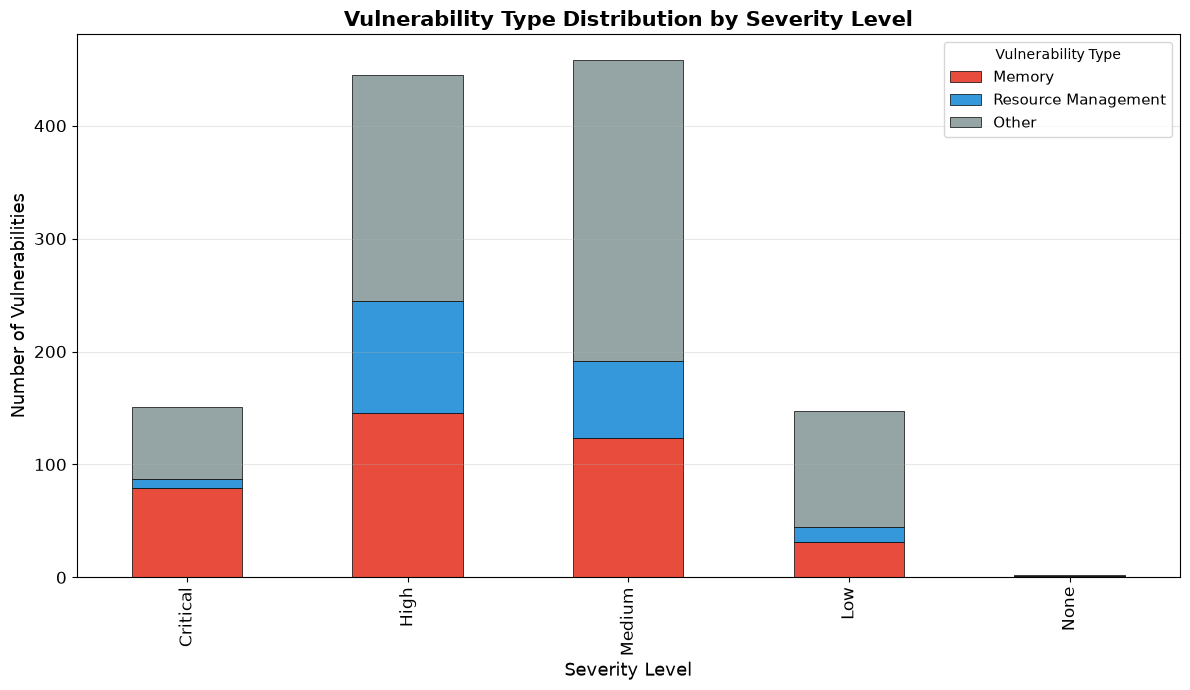

Saved: fig/rq7/severity_by_vul_type_stacked.png


In [8]:
# Create stacked bar chart showing vulnerability type distribution within each severity
fig, ax = plt.subplots(figsize=(12, 7))

# Reorder columns and rows
cross_tab_ordered = cross_tab.reindex(severity_order)[vul_types]
cross_tab_pct_ordered = cross_tab_pct.reindex(severity_order)[vul_types]

# Plot stacked bar chart
colors = ['#e74c3c', '#3498db', '#95a5a6']  # Red for Memory, Blue for RM, Gray for Other
cross_tab_ordered.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Severity Level', fontsize=13)
ax.set_ylabel('Number of Vulnerabilities', fontsize=13)
ax.set_title('Vulnerability Type Distribution by Severity Level', fontsize=15, fontweight='bold')
ax.legend(title='Vulnerability Type', loc='upper right', fontsize=11)
ax.tick_params(axis='both', labelsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig/rq7/severity_by_vul_type_stacked.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/rq7/severity_by_vul_type_stacked.png")

## Visualization 2: Grouped Bar Chart (Percentages)

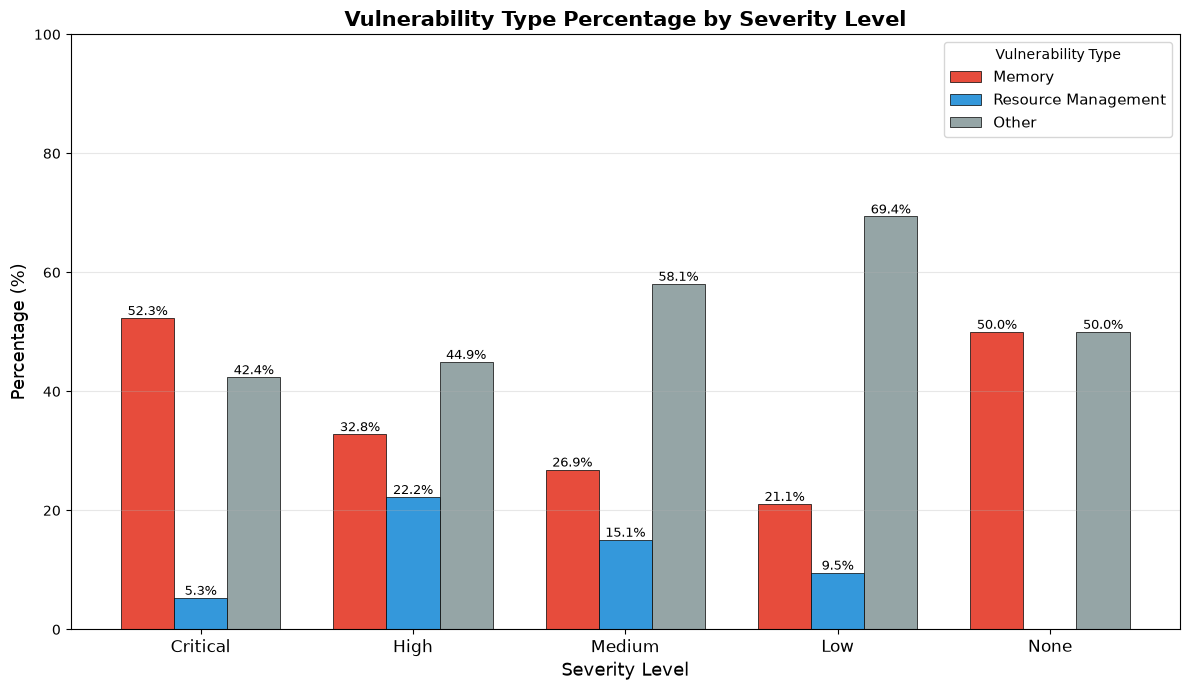

Saved: fig/rq7/severity_by_vul_type_pct.png


In [9]:
# Create grouped bar chart showing percentages
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(severity_order))
width = 0.25

memory_pct = [cross_tab_pct_ordered.loc[s, 'Memory'] if s in cross_tab_pct_ordered.index else 0 for s in severity_order]
rm_pct = [cross_tab_pct_ordered.loc[s, 'Resource Management'] if s in cross_tab_pct_ordered.index else 0 for s in severity_order]
other_pct = [cross_tab_pct_ordered.loc[s, 'Other'] if s in cross_tab_pct_ordered.index else 0 for s in severity_order]

bars1 = ax.bar(x - width, memory_pct, width, label='Memory', color='#e74c3c', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, rm_pct, width, label='Resource Management', color='#3498db', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, other_pct, width, label='Other', color='#95a5a6', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Severity Level', fontsize=13)
ax.set_ylabel('Percentage (%)', fontsize=13)
ax.set_title('Vulnerability Type Percentage by Severity Level', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(severity_order, fontsize=12)
ax.legend(title='Vulnerability Type', loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 5:  # Only label if bar is tall enough
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig/rq7/severity_by_vul_type_pct.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/rq7/severity_by_vul_type_pct.png")

## Visualization 3: Heatmap of Severity × Vulnerability Type

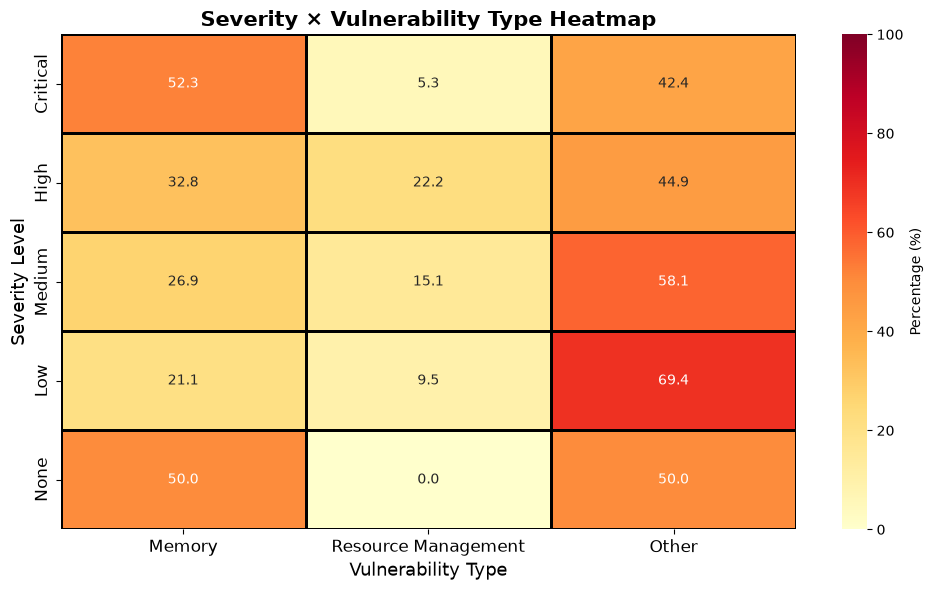

Saved: fig/rq7/severity_vul_type_heatmap.png


In [10]:
# Create heatmap
fig, ax = plt.subplots(figsize=(10, 6))

# Plot heatmap with percentages
sns.heatmap(cross_tab_pct_ordered, 
            annot=True, 
            fmt='.1f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'},
            linewidths=1,
            linecolor='black',
            vmin=0, 
            vmax=100)

ax.set_xlabel('Vulnerability Type', fontsize=13)
ax.set_ylabel('Severity Level', fontsize=13)
ax.set_title('Severity × Vulnerability Type Heatmap', fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('fig/rq7/severity_vul_type_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/rq7/severity_vul_type_heatmap.png")

## Summary and Key Findings

In [11]:
print("=" * 70)
print("SUMMARY OF FINDINGS")
print("=" * 70)

# Calculate overall percentages
total_memory = cross_tab['Memory'].sum()
total_rm = cross_tab['Resource Management'].sum()
total_other = cross_tab['Other'].sum()
total_all = total_memory + total_rm + total_other

print(f"\nOverall vulnerability type distribution:")
print(f"  Memory: {total_memory} ({total_memory/total_all*100:.1f}%)")
print(f"  Resource Management: {total_rm} ({total_rm/total_all*100:.1f}%)")
print(f"  Other: {total_other} ({total_other/total_all*100:.1f}%)")

# Calculate severity distribution
print(f"\nSeverity distribution:")
for severity in severity_order:
    if severity in cross_tab.index:
        count = cross_tab.loc[severity].sum()
        pct = count / total_all * 100
        print(f"  {severity}: {count} ({pct:.1f}%)")
# Note: percentages above are over scored CVEs only (total_all = 1203);
# the 42 CVEs with blank severity are excluded (see cell 2).
print(f"  (Excluded: {int(df_cve['severity'].isna().sum())} CVEs with blank severity, "
      f"no score)")

# Key insights
print(f"\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

# Find which severity has highest memory percentage
if 'Memory' in cross_tab_pct_ordered.columns:
    max_memory_severity = cross_tab_pct_ordered['Memory'].idxmax()
    max_memory_pct = cross_tab_pct_ordered['Memory'].max()
    print(f"\n1. Memory vulnerabilities are most prevalent in: {max_memory_severity} ({max_memory_pct:.1f}%)")

# Find which severity has highest RM percentage
if 'Resource Management' in cross_tab_pct_ordered.columns:
    max_rm_severity = cross_tab_pct_ordered['Resource Management'].idxmax()
    max_rm_pct = cross_tab_pct_ordered['Resource Management'].max()
    print(f"2. Resource Management vulnerabilities are most prevalent in: {max_rm_severity} ({max_rm_pct:.1f}%)")

# Compare mean severity
print(f"\n3. Mean severity comparison:")
print(f"   Memory: {memory_scores.mean():.2f}")
print(f"   Resource Management: {rm_scores.mean():.2f}")
print(f"   Other: {other_scores.mean():.2f}")

if memory_scores.mean() > rm_scores.mean():
    print(f"   → Memory vulnerabilities are MORE severe on average")
elif memory_scores.mean() < rm_scores.mean():
    print(f"   → Resource Management vulnerabilities are MORE severe on average")
else:
    print(f"   → Memory and Resource Management vulnerabilities have SIMILAR severity")

print(f"\n4. Research implication:")
if memory_scores.mean() > rm_scores.mean():
    print(f"   Memory vulnerabilities are more severe, so their decline is particularly important")
    print(f"   for improving Rust ecosystem security.")
else:
    print(f"   The severity distribution suggests different priorities for security focus.")


SUMMARY OF FINDINGS

Overall vulnerability type distribution:
  Memory: 380 (31.6%)
  Resource Management: 190 (15.8%)
  Other: 633 (52.6%)

Severity distribution:
  Critical: 151 (12.6%)
  High: 445 (37.0%)
  Medium: 458 (38.1%)
  Low: 147 (12.2%)
  None: 2 (0.2%)
  (Excluded: 42 CVEs with blank severity, no score)

KEY INSIGHTS

1. Memory vulnerabilities are most prevalent in: Critical (52.3%)
2. Resource Management vulnerabilities are most prevalent in: High (22.2%)

3. Mean severity comparison:
   Memory: 2.71
   Resource Management: 2.53
   Other: 2.35
   → Memory vulnerabilities are MORE severe on average

4. Research implication:
   Memory vulnerabilities are more severe, so their decline is particularly important
   for improving Rust ecosystem security.
